# End Semester Practical Examination
### Name: Yash Kumar
---
## Part A — Brain MRI Tumor Classification using CNN
**Objective:** Develop a CNN model to classify MRI brain scans into:
- **Tumor** (glioma / meningioma / pituitary)
- **No Tumor**

In [1]:
# A1 — Install dependencies
!pip -q install kagglehub tensorflow opencv-python matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: c:\Users\Ohi\anaconda3\python.exe -m pip install --upgrade pip


In [2]:
# A2 — Download Brain MRI Dataset from Kaggle
import kagglehub, shutil, os

cache_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

local_path = "./brain_tumor_dataset"
shutil.copytree(cache_path, local_path, dirs_exist_ok=True)

print("Dataset available at:", os.path.abspath(local_path))
path = local_path

Dataset available at: c:\Users\Ohi\Desktop\DLL_Lab_Exam\brain_tumor_dataset


In [3]:
# A3 — Load and Resize/Normalize Images
import os, cv2, numpy as np

IMG_SIZE = 128
X, y = [], []
tumor_classes = ["glioma", "meningioma", "pituitary"]

for root, dirs, files in os.walk(path):
    folder_name = os.path.basename(root).lower()
    if folder_name in tumor_classes:
        label = 1
    elif folder_name == "notumor":
        label = 0
    else:
        continue
    for file in files:
        img_path = os.path.join(root, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0
        X.append(img)
        y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print(f"Total Images  : {len(X)}")
print(f"X Shape       : {X.shape}")
print(f"Tumor Images  : {np.sum(y == 1)}")
print(f"No-Tumor Imgs : {np.sum(y == 0)}")

Total Images  : 7200
X Shape       : (7200, 128, 128, 3)
Tumor Images  : 5400
No-Tumor Imgs : 1800


In [4]:
# A4 — Train / Test Split (80-20, stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}   Test: {len(X_test)}")

Train: 5760   Test: 1440


In [5]:
# A5 — Design CNN Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, BatchNormalization,
                                      Flatten, Dense, Dropout)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')          # Binary: Tumor / No Tumor
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Ohi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,185 (24.86 MB)

 Trainable params: 6,516,737 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
# A6 — Train CNN Model using TensorFlow / Keras
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 134s 799ms/step - accuracy: 0.9053 - loss: 0.7348 - val_accuracy: 0.7587 - val_loss: 4.9035
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 157s 964ms/step - accuracy: 0.9477 - loss: 0.1758 - val_accuracy: 0.8281 - val_loss: 2.5200
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 159s 984ms/step - accuracy: 0.9539 - loss: 0.1395 - val_accuracy: 0.8854 - val_loss: 1.3211
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.9610 - loss: 0.1158 - val_accuracy: 0.9635 - val_loss: 0.1227
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9585 - loss: 0.1301 - val_accuracy: 0.9618 - val_loss: 0.1369


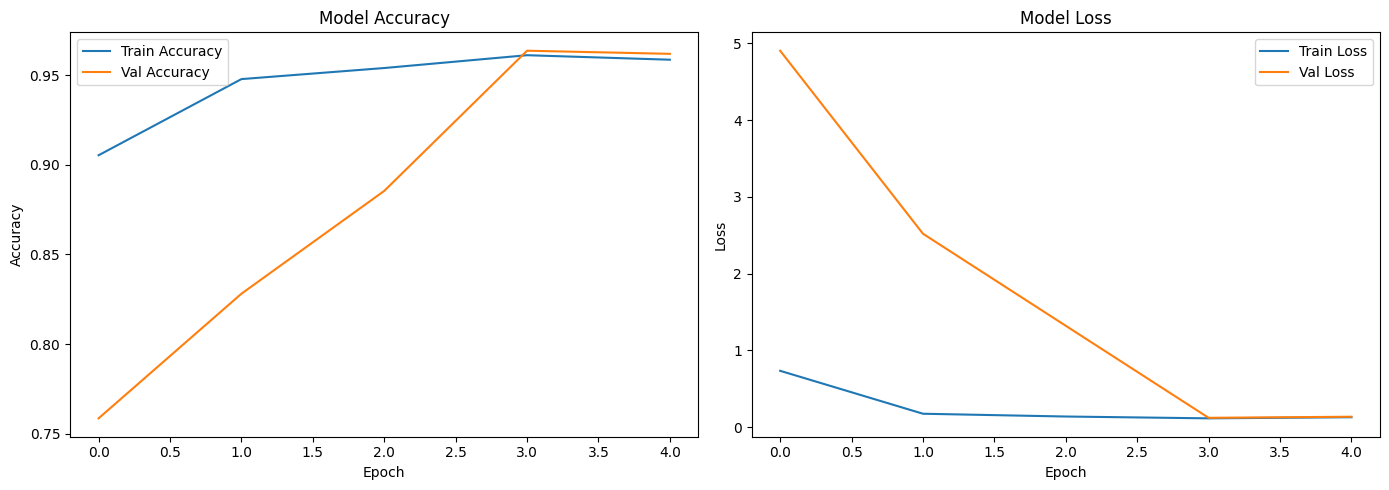

In [7]:
# A7 — Plot Training & Validation Accuracy / Loss
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100)
plt.show()

Test Loss     : 0.1628
Test Accuracy : 95.42%
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 219ms/step


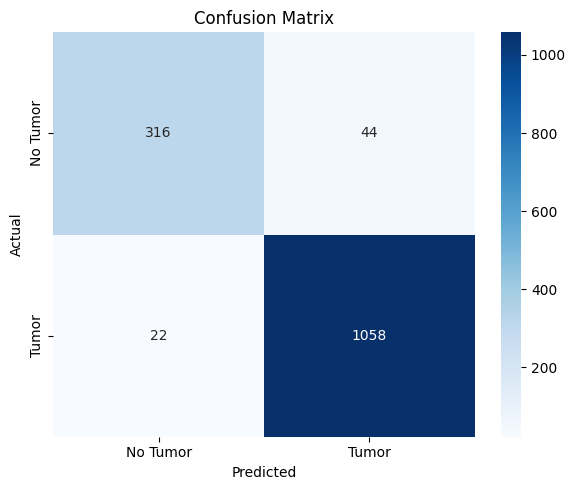


Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.93      0.88      0.91       360
       Tumor       0.96      0.98      0.97      1080

    accuracy                           0.95      1440
   macro avg       0.95      0.93      0.94      1440
weighted avg       0.95      0.95      0.95      1440



In [8]:
# A8 — Evaluate Model Performance
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc*100:.2f}%")

pred = (model.predict(X_test) > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, pred, target_names=['No Tumor', 'Tumor']))

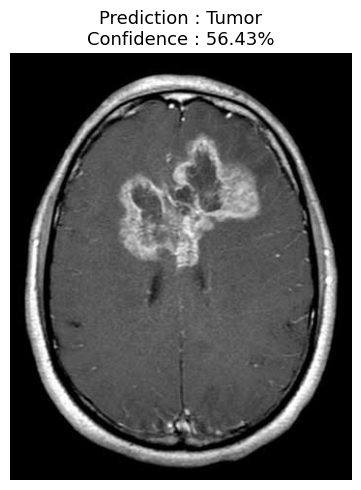

Prediction : Tumor
Confidence : 56.43%


In [9]:
# A9 — Predict on a Custom MRI Image (visualisation)
import cv2, numpy as np, matplotlib.pyplot as plt, os

# Pick one sample from the dataset automatically
sample_image = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            sample_image = os.path.join(root, file)
            break
    if sample_image:
        break

# ── Predict ──────────────────────────────────────────────────────────────────
img      = cv2.imread(sample_image)
img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_in   = cv2.resize(img, (128, 128)).astype("float32") / 255.0
prob     = model.predict(np.expand_dims(img_in, axis=0), verbose=0)[0][0]
label    = "Tumor" if prob > 0.5 else "No Tumor"
conf     = max(prob, 1 - prob) * 100

# ── Display ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Prediction : {label}\nConfidence : {conf:.2f}%", fontsize=13)
plt.tight_layout()
plt.savefig("prediction_output.png", dpi=100)
plt.show()

print("Prediction :", label)
print(f"Confidence : {conf:.2f}%")

---
## Part B — CNN Explainability (Interpret Learned Features)
**Objective:** Interpret what the CNN has learned by visualising filters and feature maps.
- Extract filters from the **first convolution layer**
- Visualise **feature maps** from an intermediate layer
- Concepts: Explainable AI, CNN Interpretability

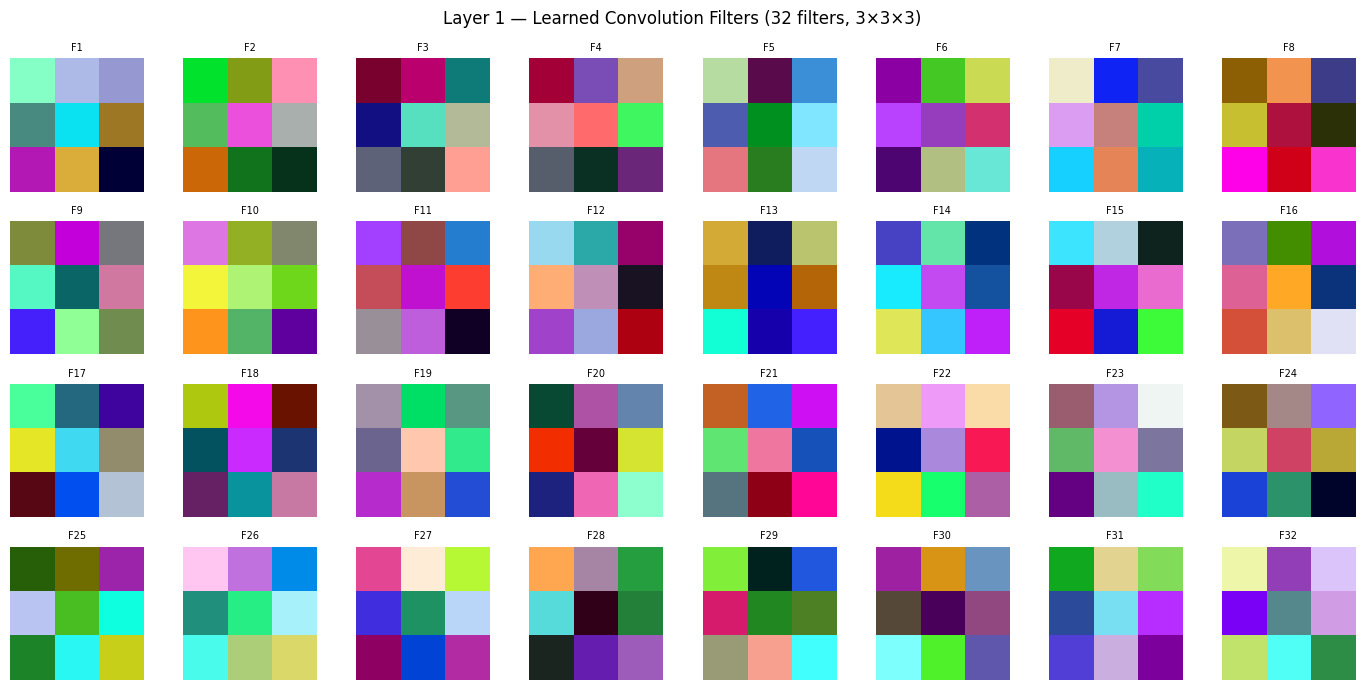

Displayed 32 filters from the first Conv2D layer.


In [10]:
# B1 — Visualise Filters from First Convolution Layer
import matplotlib.pyplot as plt
import numpy as np

filters, biases = model.layers[0].get_weights()   # shape: (3,3,3,32)

# Normalise each filter to [0,1] for display
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle("Layer 1 — Learned Convolution Filters (32 filters, 3×3×3)", fontsize=12)

for i, ax in enumerate(axes.flat):
    f = filters[:, :, :, i]
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f)
    ax.set_title(f"F{i+1}", fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.savefig("layer1_filters.png", dpi=100)
plt.show()
print("Displayed 32 filters from the first Conv2D layer.")

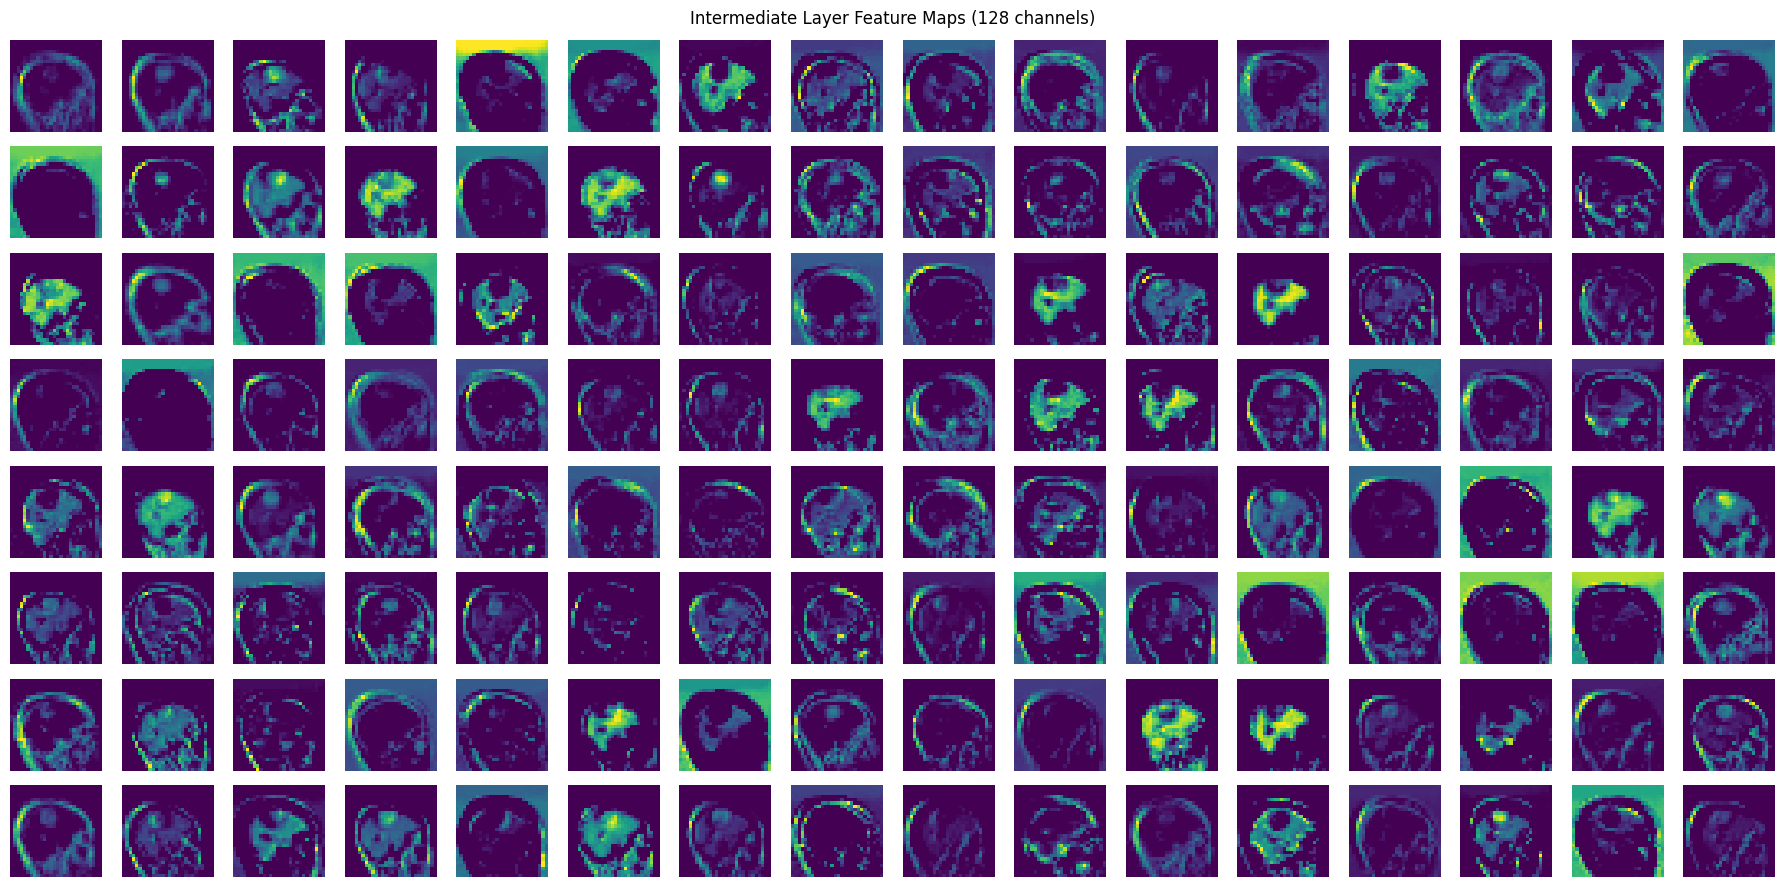

Feature map shape: (1, 28, 28, 128)  →  128 channels visualised


In [11]:
# B2 — Visualise Feature Maps from Intermediate (3rd Conv) Layer
from tensorflow.keras.models import Model

# Index 6 is the third Conv2D (after BN + Pool pairs)
feature_model = Model(inputs=model.inputs, outputs=model.layers[6].output)

# Use first test image
sample_input = np.expand_dims(X_test[0], axis=0)
feature_maps = feature_model.predict(sample_input, verbose=0)

fig, axes = plt.subplots(8, 16, figsize=(18, 9))
fig.suptitle("Intermediate Layer Feature Maps (128 channels)", fontsize=12)

for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[-1]:
        fmap = feature_maps[0, :, :, i]
        ax.imshow(fmap, cmap='viridis')
    ax.axis("off")

plt.tight_layout()
plt.savefig("feature_maps.png", dpi=100)
plt.show()
print(f"Feature map shape: {feature_maps.shape}  →  {feature_maps.shape[-1]} channels visualised")

c:\Users\Ohi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


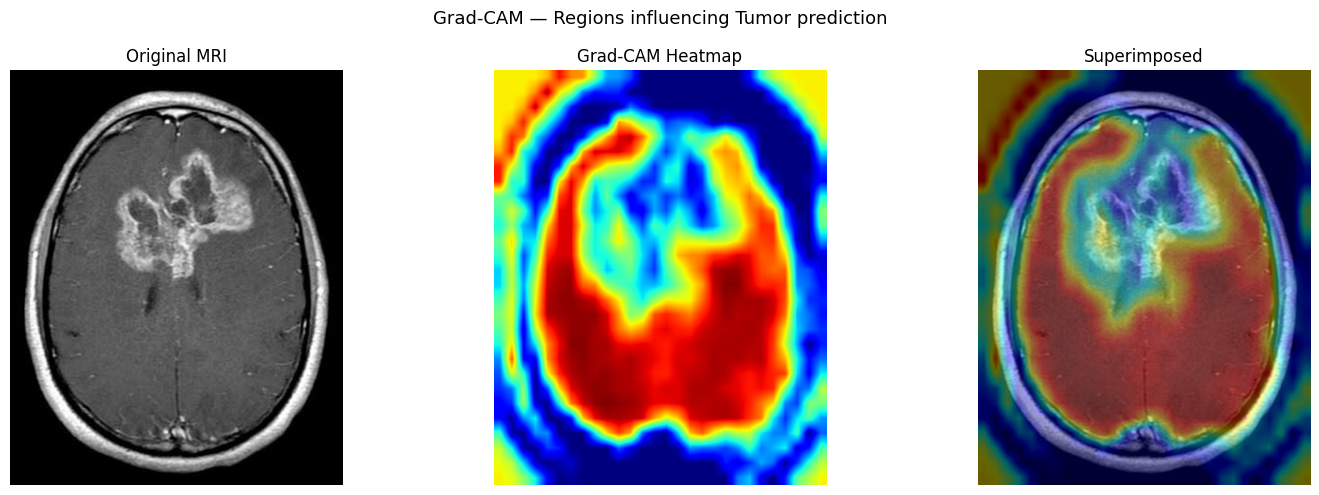

In [12]:
# B3 — Grad-CAM Heatmap (Explainable AI)
import tensorflow as tf
import cv2, numpy as np, matplotlib.pyplot as plt

# ── Grad-CAM helper ──────────────────────────────────────────────────────────
def grad_cam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.outputs[0]]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]
    grads    = tape.gradient(loss, conv_out)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam      = conv_out[0] @ pooled[..., tf.newaxis]
    cam      = tf.squeeze(cam).numpy()
    cam      = np.maximum(cam, 0)
    cam      = cam / (cam.max() + 1e-8)
    return cam

# ── Pick sample image ────────────────────────────────────────────────────────
img_bgr  = cv2.imread(sample_image)
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_in   = cv2.resize(img_bgr, (128, 128)).astype("float32") / 255.0
img_arr  = np.expand_dims(img_in, axis=0)

# Last Conv2D layer name
last_conv = [l.name for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]
cam       = grad_cam(model, img_arr, last_conv)

# Resize heatmap to original image size
h, w = img_rgb.shape[:2]
heatmap = cv2.resize(cam, (w, h))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
superimposed   = (0.6 * img_rgb + 0.4 * heatmap_colored).astype(np.uint8)

# ── Display ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb);         axes[0].set_title("Original MRI");    axes[0].axis("off")
axes[1].imshow(heatmap, cmap='jet'); axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis("off")
axes[2].imshow(superimposed);    axes[2].set_title("Superimposed");    axes[2].axis("off")
plt.suptitle("Grad-CAM — Regions influencing Tumor prediction", fontsize=13)
plt.tight_layout()
plt.savefig("gradcam.png", dpi=100)
plt.show()